# Krachtactuator Ontwerpopdracht

In de eerste 4 weken van het vak DEF-D hebben jullie simulaties gedaan van verschillende opstellingen in de electrostatica. Jullie zijn in week 3.6 bij het vak electromagnetisme doorgegaan met de magnetostatica. Deze opdracht gaat in op het simuleren van deze magnetostatica.

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

De opdracht bestaat uit de volgende sub-onderdelen:
1) Afleiden van een analytische vergelijking
2) Criteria opstellen
3) Simuleren om de grenzen van jullie ontwerpparameters te bepalen
4) Numeriek berekenen van het magneetveld
5) Numeriek berekenen van het magneetveld van een solenoide
6) Bereken krachtrespons van een kracht actuator
7) Beoordeling van de criteria

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.9 beoordeeld en herkansingen zijn in week 3.10, zie de studiehandleiding voor details.

Technische Instructies:
- Download de zip map die op brightspace staat en unzip deze.
- Creëer een nieuwe branch in je Github repo voor deze opdracht.
- Plaats de geunzipte map op de juiste plek in jouw branch, zoals in de handleiding op brightspace staat.
- Nodig je teamgenoot uit als collaborateur op jouw repo.

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Probeer de voorbeeld code te begrijpen.
- Op een aantal plekken zijn voorbeelden gegeven of bepaalde numerieke methodes sterk versimpeld. Deze code kunnen reprocuderen is niet een leerdoel van dit vak en zal later in de opleiding voorkomen. Denk hierbij aan het integreren en differentieeren, probeer deze dingen wel te begrijpen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# DEF-D opdracht 2: Ontwerp een solenoïdale krachtactuator


<img align="right" style="margin-left:15px" src="figures\solenoidactuator.png" width="600">


In deze ontwerpopdracht ga je een krachtactuator ontwerpen gebaseerd op een solenoïde en een permanente magneet. Deze lineaire krachtactuatoren worden gebruikt om bijvoorbeeld kleppen en afsluiters elektronisch te bedienen. Ook komen ze in vele huidshoudelijk apparaten voor. Hiernaast zie je een plaatje van een krachtactuator van de buitenkant en van de doorsnede. De krachtactuator bestaat uit een solenoïde (spoel), dat is een spiraalvormige stroomkring waar een stroom doorheen loopt. Zoals je weet kan je met een solenoide een redelijk homogeen veld maken als de solenoide lang en smal is. In de solenoïde  zit een cilinder,een zogeheten plunjer, die kan schuiven in de solenoïde. De plunjer is verbonden met het object dat je wilt bewegen. De plunjer kan gemaakt zijn van een magnetisch materiaal met een hoge magnetische permeabiliteit of van een permanente magneet. In dit voorbeeld kiezen we voor een plunjer van magnetiseerbaar materiaal.

Voor het ontwerpen van de actuator gaan we eerst de kracht van de actuator uitrekenen met behulp van analytische theorie. We nemen eerst aan dat de solenoïde ideaal is en leiden daarvoor een analytische vergelijking af. Nadat we een eerste ontwerp hebben gemaakt gebaseerd op de analytische oplossing gaan we simuleren hoe goed onze krachtactuator echt werkt en of we het ontwerp nog kunnen verbeteren. Daar gaan we!

## Deel 1: afleiden van een analytische vergelijking

Hier onder ze je een detaildoorsnede van de solenoïde. De solenoïde heeft een lengte $L_s$, $N$ wikkelingen, een straal $r_s$ en er loopt een constante stroom $I$ door de draad. De plunjer is een afstand $z_p$ in de solenoide geschoven en moet over een zo groot mogelijke afstand een kracht uitoefenen. Een ideale solenoïde heeft binnenin een constant veld dat overal langs de as is gericht, buiten de solenoïde is het veld nul. Daarnaast nemen we aan dat het magnetisch materiaal homogeen en lineair is en een relatieve permeabiliteit $\mu_r$ heeft.

<center>
<img src="figures\solenoidactuatorgraph.png" width="1000">
</center>

**Opdracht 1**

a. Pas de wet van Ampère toe voor het $\mathbf{H}$-veld met gebruik van contour $\cal C$.\
b. Leidt een vergelijking af voor het $\mathbf{B}$-veld als functie van $z_p$.\
c. Voldoet jouw afleiding aan de randvoorwaarden voor het H en B veld?

Voeg jullie afleiding hier als png toe.

![alt text](<figures/foto opdracht 1.png>)

Het randveld van de solenoïde zal de plunjer de solenoïde intrekken. Echter, het berekenen van de randvelden is een hele klus, we zullen dit later doen. We gebruiken hier een aanpak soortgelijk aan die voor een dielektricum in een condensator. Allereerst berekenen we de totale energie van het systeem met behulp van $W = \frac{1}{2} \int_{\cal V} \mathbf{H} \cdot \mathbf{B} \, d\tau $. Daarna bepalen we de kracht op de plunjer door de afgeleide van de energie naar de positie te nemen. We nemen aan dat de plunjer dezelfde straal heeft als de solenoide, $r_s$. 

**Opdracht 2**

Bereken de totale hoeveelheid energie in de solenoïde als functie van $z_d$ door de veldenergie over het volume van de solenoïde te integreren met behulp van bovenstaande vergelijking.

Voeg jullie afleiding hier als png toe.

![alt text](<figures/foto opdracht 2.png>)

Zoals je wellicht ziet uit je afleiding is de energie van de plunjer groter als de plunjer er geheel uit is en kleiner als de plunjer er geheel in is. De afgeleide van de energie naar de positie $z_p$ geeft dan ook een kracht die de plunjer naar buiten beweegt. Dit is fysisch niet wat er gebeurd. Wat we in de afleiding niet hebben meegenomen is de energie die het kost om de stroom te laten stromen. Het veranderende magneetveld veroorzaakt door het naar binnen bewegen van de magneet (wet van Faraday) geeft een stroom tegengesteld aan de aangelegde stroom, de stroombron moet dan dus meer vermogen gaan leveren om de stroom op gang te houden. Als we dit effect wel meenemen blijkt dat de grootte van de kracht gelijk is, maar dat deze dan de plunjer de solenoide intrekt. We gaan hier niet verder op in.


**Opdracht 3**

Bereken de kracht van de spoel op de plunjer.

Voeg hier een png toe van jullie afleiding.

![alt text](<figures/foto opgave 3.png>)

## Deel 2: Criteria opstellen

Jullie gaan nu een magnetische kracht actuator ontwerpen hiervoor gaan jullie nu een ontwerpcyclus doorlopen.

**Opdracht 4**

a. Bedenk en schets vijf toepassingen van een kracht actuator.\
b. Kies uit deze toepassingen minimaal 2 toepassingen voor een kracht actuator om verder mee door te rekenen.

Plaats hier een foto van jullie vijf schetsen met uitleg over wat er te zien is.

![alt text](<figures/opdracht 4.png>)

we hebben gekozen om verder te werken met het fietsslot en het speelgoedpistool

**Opdracht 5**

We gaan nu verder kijken naar de criteria van jullie kracht actuatoren. Wij hebben alvast twee essentiele criteria vastgesteld zodat we hier later in de opdracht mee verder kunnen rekenen. Hieronder zijn 4 veelgebruikte stroombronnen benoemd die jullie gaan gebruiken voor een van de criteria.

| Spanningsbron             | Stroomsterkte | Voltage | draad dikte van de spoel |
|:--------------------------|:--------------|:--------|:-------------------------|
| Arduino uno digital pin   | 40 mA         | 5 V     | 0.05 mm                  |
| 9 Volt batterij           | 500 mA        | 9 V     | 0.1  mm                  |
| 40 Watt telefoon oplader | 2 A           | 20 V    | 0.2 mm                   |
| Een auto batterij         | 180 A         | 12 V    | 1.5 mm                   |


a. Kies een van de hierboven benoemde stroombronnen om te gebruiken in jullie ontwerp. \
b. Gebruik de methode uit het college 'schattend rekenen' om voor elke toepassing de minimale kracht die de actuator moet kunnen leveren voor jullie toepassing te bepalen.\
c. Denk na over wat de straal van jullie actuator mag zijn. \
d. Bedenk nog 1 ander criterium per toepassing.

Plaats hier een foto van jullie uitwerkingen op vraag 5.

a) voor het fietsslot gebruiken we de 40 watt telefoonoplader, voor het speelgoed pistool de 9 v batterij\
b) speelgoedpistool: stel dat de veer een indrukking heeft van 2 cm en je hem met je vinger redelijk makkelijk kunt indrukken, dan is de kracht van een vinger gemiddeld 10 tot 20 N. Dus we schatten de benodigde kracht op F = 5 N.\
fietsslot: het slot van een fiets is soms stroef en moet je wat kracht zetten. Dat is ongeveer 4 kg, dus ongeveer 40 N.\
c) voor het speelgoedpistool moet hij in het frame passen, dus is ongeveer 5 mm goed\
het fietsslot mag groter zijn, dus is ongeveer 15 mm goed\
d) fietsslot: hij mag niet te lang aan staan, omdat die een hoge stroomsterkte heeft\
speelgoedpistool: hij moet snel reageren, anders is het speelgoed sloom


## Deel 3: Simuleren om de grenzen van jullie ontwerpparameters te bepalen

Jullie zullen nu simulaties gaan uitvoeren om de grenzen van jullie ontwerpparameters op te zoeken. Dit doen jullie voor jullie twee gekozen toepassingen en een deuractuator. Deze deuractuator moet een deur van het slot afhaalen door een kracht van 40 N uit te oefenen, gebruikt een 9 volt batterij als stroombron, de plunjer is gemaakt van ijzer en de straal van de actuator is 0.01 m.

**Opdracht 6**

Zet de relevante parameters in een Python script en maak een Python functie die met behulp van de wet van Ohm de maximale draadlengte uitrekent. Print de maximale draadlengte bij het uitvoeren van het script.

Plaats in deze cel een png met jullie eventuele analytische uitwerkingen.

![alt text](<figures/opdracht 6.png>)

In [2]:
#deuractuator
F_deur = 40 #N
V_deur = 9 #V
r_deur= 0.01 #m
I_deur = 0.5 #A

#fietsslot
F_fiets = 40 #N
V_fiets = 20 #V
r_fiets= 0.05 #m
I_fiets = 2 #A

#speelgoedpistool
F_pistool= 5 #N
V_pistool= 9 #V
r_pistool= 0.01 #m
I_pistool= 0.5 #A

r_draad_9V = 0.1 / 1000  # 0.1 mm diameter
r_draad_20V = 0.2 / 1000  # 0.1 mm diameter

def lengte_actuator (V,r,I):
    rho_koper= 0.0175*10**(-6)
    L=np.pi*V*r**2/(rho_koper*I)
    return L

Lengte_deur= lengte_actuator(V_deur, r_draad_9V, I_deur)
Lengte_fiets= lengte_actuator(V_fiets, r_draad_20V, I_fiets)
Lengte_pistool= lengte_actuator(V_pistool, r_draad_9V, I_pistool)

print('de maximale draadlengte voor de actuator van de deur is %.2f m'%Lengte_deur)
print('de maximale draadlengte voor de actuator van het fietsslot is %.2f m'%Lengte_fiets)
print('de maximale draadlengte voor de actuator van het speelgoedpistool is %.2f m'%Lengte_pistool)

de maximale draadlengte voor de actuator van de deur is 32.31 m
de maximale draadlengte voor de actuator van het fietsslot is 71.81 m
de maximale draadlengte voor de actuator van het speelgoedpistool is 32.31 m


**Opdracht 7**

Leidt een vergelijking af voor het minimale aantal wikkelingen $N$ die je nodig hebt om het gewicht op te kunnen tillen. Voeg je afleiding als png toe aan je notebook.

Plaats hier een png met jullie afleiding.

![alt text](<figures/opdracht 7.png>)

We gaan nu de ontwerpvrijheid verkennen. Gegeven de materiaalparameters en de eigenschappen van de stroombron kunnen we de verhouding tussen de lengte en de straal van de solenoide kiezen.

**Opdracht 8**

Schrijf een enkele Python functie die het minimum en maximum aantal wikkelingen uitrekent als functie van $L_s$, $r_s$, $r_d$ en $I$. De functie moet de volgende voorwaarden controleren
1) Het minimum aantal wikkelingen wordt gegeven door de hiervoor afgeleide relatie van het aantal wikkelingen om de benodigde kracht te genereren. 
2) Het maximum aantal wikkelingen wordt gegeven door de draaddikte $r_d$ en de lengte $L_s$
3) Het maximum aantal wikkelingen wordt gegeven door de draadlengte en de straal van de solenoide
4) Het maximum aantal wikkelingen moet groter zijn dan het minimum aantal wikkelingen

Het maximum aantal wikkelingen is de kleinste van voorwaarde 2) en 3). Geef een foutmelding als het minimum aantal windingen groter is dan het maximum aantal windingen.

Plaats hier een png met jullie eventuele analytische afleiding.

In [3]:
### BEGIN SOLUTION
mu_r=50000 #relative permeabiliteit van ijzer
mu_0= 4*np.pi*10**(-7) #permeabiliteit vacuum


def aantal_wikkelingen(F, L_s, r_s, I, L_draad, r_draad):
    # Voeg hieronder de formules voor het maximum en minimum aantal wikkelingen.
    N_min = L_s/(r_s*I)*np.sqrt(2*F/(np.pi*mu_0*(mu_r-1)))
    N_max_1 = L_s/(2*r_draad)
    N_max_2 = L_draad/(2*np.pi*r_s)

    N_max = np.minimum(N_max_1, N_max_2)
    #if N_min > N_max: ## Als het ontwerp niet mogelijk is.
    #    print('The design with %.1f unit has no workable solution'%N_max)
    #    print('N_max is', N_max)
    #    print('N_min is', N_min)
    #    N_min = 'NaN'
    #    N_max = 'NaN'
    N_min = np.where(N_min > N_max, np.nan, N_min)
    N_max = np.where(np.isnan(N_min), np.nan, N_max)
    return N_min, N_max

L_s_array = np.linspace(0.00, 1.0, 50)

N_min_res, N_max_res = aantal_wikkelingen(40, L_s_array, r_deur, I_deur, Lengte_deur, r_draad_9V)
print(N_min_res)
print(N_max_res)

[  0.          82.17096393 164.34192785 246.51289178 328.6838557
 410.85481963 493.02578355          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan]
[  0.         102.04081633 204.08163265 306.12244898 408.16326531
 510.20408163 514.28571429          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          nan          nan          nan          nan          nan
          

Een parameter plot geeft ons inzicht in de haalbaarheid van het idee. In dit geval willen we kijken naar het mogelijke aantal wikkelingen en de lengte van onze solenoide. Hieronder staat een voorbeeld van code die een voorbeeld plot creëert met minimale eis $y=x$ en de maximale eis $y=2x$.

Text(0, 0.5, 'y')

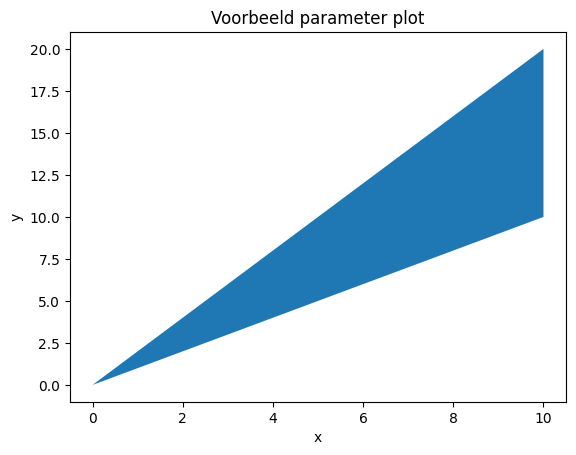

In [4]:
x = np.linspace(0,10,100)
y_min = x # Minimale eis
y_max = 2*x # Maximale eis

plt.fill_between(x,y_min,y_max) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")

**Opdracht 9**

Maak een parameterplot met behulp van bovenstaand gedefinieerde functie voor de drie solenoideactuatoren voor $L_s$ tussen 0 en 1 m in 50 stappen. Een parameter plot ziet er hier uit als een plot tussen het minimale aantal wikkelingen en het maximaal aantal wikkelingen.



Text(0, 0.5, 'y')

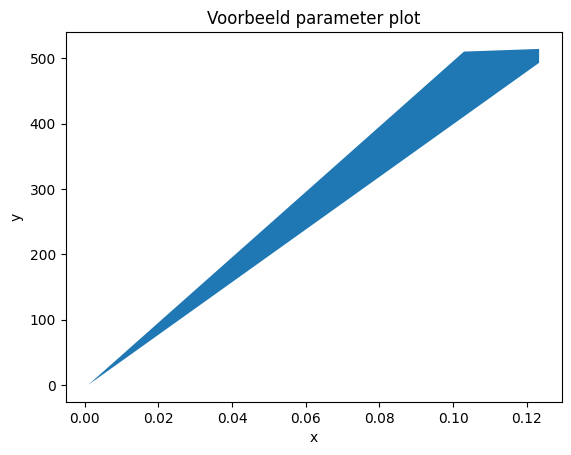

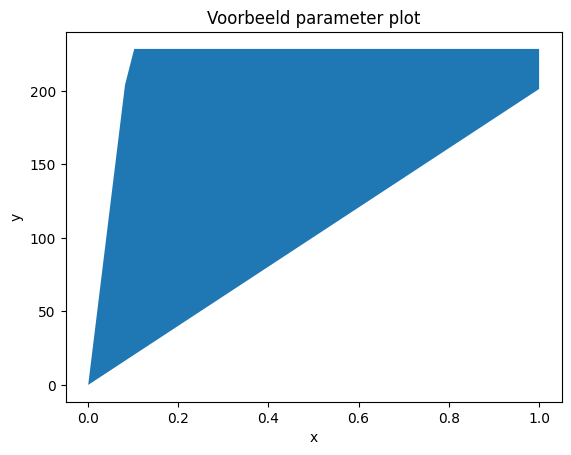

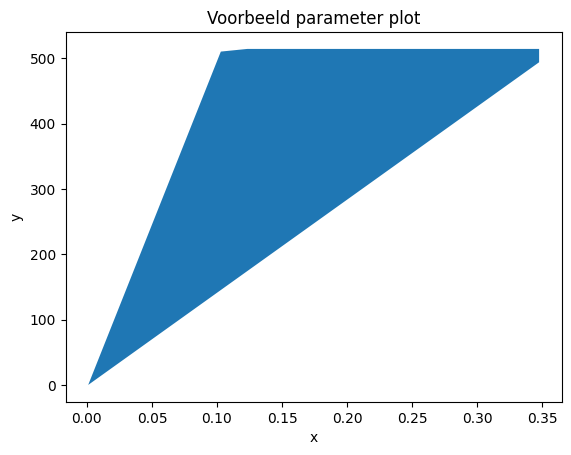

In [5]:
Ls_stappen = np.linspace(0.001, 1.0, 50) 
rho_koper = 0.0175e-6

plt.figure()
plt.fill_between(Ls_stappen, N_min_res, N_max_res) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")

N_min_fietsslot, N_max_fietsslot = aantal_wikkelingen(F_fiets, L_s_array, r_fiets, I_fiets, Lengte_fiets, r_draad_20V)

plt.figure()
plt.fill_between(Ls_stappen, N_min_fietsslot, N_max_fietsslot) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")

N_min_pistool, N_max_pistool = aantal_wikkelingen(F_pistool, L_s_array, r_pistool, I_pistool, Lengte_pistool, r_draad_9V)

plt.figure()
plt.fill_between(Ls_stappen, N_min_pistool, N_max_pistool) # De ruimte tussen de eisen vullen
plt.title("Voorbeeld parameter plot")
plt.xlabel("x")
plt.ylabel("y")

**Opdracht 10**

Maak voor elke actuator een keuze voor de lengte van de spoel, de straal van de spoel en de lengte van de draad.

deur: 5 cm , 1 cm, 15 m \
fietsslot: 5 cm, 1 cm,  10 m.\
speelgoedpistool: 10 cm, 1 cm, 20 m.

Bovenstaande analytische berekening is een goede start voor het ontwerp en geeft aan welke parameters je kan optimaliseren. Echter in een echte solenoide zullen er allerlei niet ideale effecten een rol spelen. Zo zal het veld in de solenoide niet constant zijn (het is geen oneindig lange solenoide) en zijn er randvelden aan de uiteinden van de solenoide. We zullen nu de kracht-afstand relatie van de solenoide krachtactuator uitrekenen. Deze kan dan verder geoptimaliseerd worden om de kracht-uitwijking relatie zo lineair mogelijk te maken.

## Deel 4: Numeriek berekenen van het magneetveld van een rechte stroomdraad

<img align="right" style="margin-left:15px" src="wiregeometry.jpg" width="300">

Omdat we in ons ontwerp een stroombron gebruiken met een aangelegde stroom voeren we de berekeningen uit met het $\mathbf{H}$-veld. De analytische oplossing voor het $\mathbf{H}$-veld om een oneindig lange stroomdraad is het met meest eenvoudige voorbeeld voor het berekenen van het magnetisch veld en het toepassen van de wet van Ampere. In cilindrische coordinaten wordt het magneetveld op afstand $s$ veroorzaakt door stroom $I$ gegeven door (zie Griffiths blz. 282, voorbeeld 6.2)
$$
    \mathbf{B} =\frac{I}{2 \pi s} \hat{\boldsymbol{\phi}} \, .
$$


Alleen in de meest eenvoudige stroomgeometrieën kunnen we het magneetveld analytisch berekenen. In meer complexe stroomgeometrieën moeten we numerieke methoden gebruiken om het magneetveld te berekenen. In deze opdracht willen we een numerieke methode ontwikkelen voor een complexe stroomgeometrie, maar gebruiken we het voorbeeld van de oneindig lange stroomdraad om onze numerieke methode te testen. We gaan het magneetveld berekenen met de wet van Biot-Savart (zie Griffiths blz. 222, Vgl. 5.34) maar dan voor het $\mathbf{H}$-veld

$$
    \mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I \int \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

De wet van Biot-Savart laat zien dat het magneetveld wordt gegeven door een som over lijnelementen $d\mathbf{l}$ met bijdrage

$$
    d\mathbf{H}(\mathbf{r}) = \frac{1}{4 \pi} I  \frac{d \mathbf{l}' \times \widehat{(\mathbf{r} - \mathbf{r}')}}{|\mathbf{r} - \mathbf{r}'|^2} \, .
$$

**Opdracht 11**

Schrijf een Python funktie met als invoer de variabelen:
* een array die de veldpositie $\mathbf{r}$ aangeeft
* een array die de de bronpositie $\mathbf{r}'$ aangeeft
* een array die de lengte $d\mathbf{l}$ aangeeft

De functie moet het magneetveld van een lijnelement $d\mathbf{l}$ berekenen. Gebruik voor het uitrekenen van het uitproduct de numpy $\verb|cross|$ functie en de hierboven gegeven formule voor $d\mathbf{H}$.

Bereken met deze functie alle componenten van het magneetveld voor een veldpositie op $x=0.1$ m voor een stroombronelement in de oorsprong met een stroom van 6 A een lengte van $d\mathbf{l}$ gelijk aan $L/64$. Print het analytische en numerieke antwoord naar de command line en controleer dat het magneetveld gelijk is aan $\mathbf{H} =  0.00746 \hat{\mathbf{y}}$ A/m is.

In [6]:
import numpy as np

I = 6
L_draad = 0.1
dl = np.array([0, 0, L_draad/64])      # z-richting
r_field = np.array([0.1, 0, 0])       
r_source = np.array([0, 0, 0])         

def biot_savart(r_field, r_source, dl):
    # (r - r')
    R_vec = r_field - r_source
    
    # grootte van de vectxor R
    R_mag = np.linalg.norm(R_vec)
    
    # eenheidsvector
    R_unit = R_vec / R_mag
    
    # dl x R-unit
    # dl wijst omhoog, R_unit wijst naar rechts 
    # dl x R_unit wijst in de richting van de waarnemer
    cross_product = np.cross(dl, R_unit)
    
    # Wet van Biot-Savart
    dH = (I / (4 * np.pi)) * (cross_product / (R_mag**2))
    
    return dH

ana_val = (I / (4 * np.pi)) * (L_draad / 64) / np.sum((r_field - r_source)**2)
num_res = biot_savart(r_field, r_source, dl)

print(f'analytisch {ana_val:.5f} A/m in the y-direction')
print(f'Numeriek  {num_res} A/m')

analytisch 0.07460 A/m in the y-direction
Numeriek  [0.         0.07460388 0.        ] A/m


**uitleg opdracht** 
Dit is een soort sanity check zodat we weten dat we de wet van biot-savart kunnen toepasasen op onze sonoloide.

Nu gaan we met behulp van de numerieke implementatie van de wet van Biot-Savart het magneetveld uitrekenen in het vlak loodrecht op de draad. We nemen daarom een eindige lengte van de draad en verdelen dit in kleine stukken met lengte $d\mathbf{l}$. Daarna integreren we over de gehele lengte door de bijdrage van al deze stukken op te tellen en zo het magneetveld te bepalen. Voor het correct uitvoeren van deze numerieke integratie is het van belang dat we en een lang genoeg stuk draad nemen en dat we dit in genoeg kleine delen ophakken.

**Opdracht 12**
* Creëer een array met de veldcoordinaat $\mathbf{r}$.
* Bereken een array met alle contributies $dH$ op $r=(x,y,z)=(0.1, 0, 0)$ m.
* Plot de contributies tegen de locatie van de bijbehorende bron.
* Bereken het $H$ veld door over alle contributies te someren.
* Print een regel met het numerieke antwoord en vergelijk dit met het analytische antwoord.
* Bestudeer hoe de bijdragen varieren voor de verschillende locaties en hoe groot L en het aantal stappen moet zijn om een numeriek correct resultaat te krijgen.

Deze opdracht kan ook gemaakt worden met het gebruik van for loops, De akauze voor methode is aan jullie.

Numeriek (L=2.0m, N=200): 9.45486 A/m
Analytisch(oneindige draad):      9.54930 A/m
Verschil: 0.09443 A/m


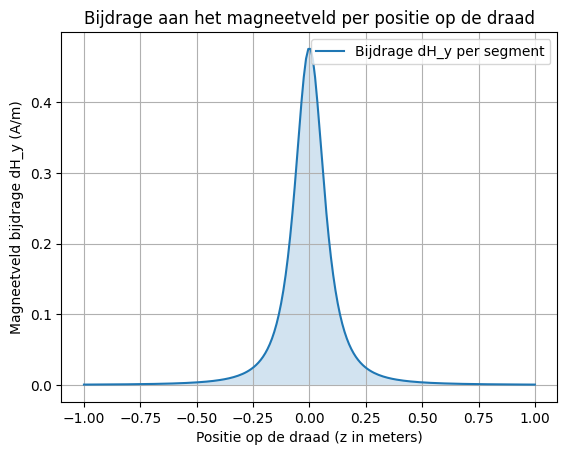

In [7]:
import numpy as np
import matplotlib.pyplot as plt

I = 6
L_totaal = 2.0          # 2 meter lang
N_stappen = 200         # 200 stukjes
r_field = np.array([0.1, 0, 0])  # meetpunt op 10 cm van de draad

# vector dl bereknenen
dz = L_totaal / N_stappen
dl = np.array([0, 0, dz])

# Bronposities (z-as) en de contributies
# Draad van -L/2 tot L/2
z_bronnen = np.linspace(-L_totaal/2, L_totaal/2, N_stappen)
dH_lijst = []

# contributie voor elk segmentje
for z in z_bronnen:
    r_source = np.array([0, 0, z])
    contributie = biot_savart(r_field, r_source, dl)
    # y-component (index 1)
    dH_lijst.append(contributie[1])

dH_lijst = np.array(dH_lijst)

# totale H-veld
H_totaal_numeriek = np.sum(dH_lijst)

# Analytisch antwoord voor een oneindig lange draad
H_totaal_analytisch = I / (2 * np.pi * 0.1)

print(f"Numeriek (L={L_totaal}m, N={N_stappen}): {H_totaal_numeriek:.5f} A/m")
print(f"Analytisch(oneindige draad):      {H_totaal_analytisch:.5f} A/m")
print(f"Verschil: {abs(H_totaal_numeriek - H_totaal_analytisch):.5f} A/m")

plt.figure()
plt.plot(z_bronnen, dH_lijst, label='Bijdrage dH_y per segment')
plt.fill_between(z_bronnen, dH_lijst, alpha=0.2)
plt.title('Bijdrage aan het magneetveld per positie op de draad')
plt.xlabel('Positie op de draad (z in meters)')
plt.ylabel('Magneetveld bijdrage dH_y (A/m)')
plt.grid(True)
plt.legend()
plt.show()

**uitleg opdracht**

De grafiek laat een klokvorm zien. Dit is logisch omdat op z = 0 is de afstand to de sensor (onze meetpunt minimaal) hier zou theoretisch de bijdrage tot het H-veld het grootst moeten zijn wat ook het geval is. Omdat de bijdrage van een klein stukje draad op een afstand van ongeveer een meter van de sensor al bijna 0 kunnen we vaak de theorie vane een oneindige draad gebruiken. 

Hieronder is een schets van de sitauatie, de richting van het magneetveld is bepaald met de rechterhandregel;

![alt text](<figures/opdracht12.jpg>)

### Deel 5: Numeriek berekenen van het magneetveld van een solenoide

We gaan nu het magneetveld van onze solenoide uitrekenen. Deze solenoide is een draad die om een cylinder gewikkeld is. Hieronder is een functie gegeven die de draad van een solenoide parametriseert. Deze parametrisatie gaan jullie gebruiken in combinatie met Biot-Savart om het H veld rond de solenoide te berekenen.

In [8]:
def parametrisatie(N,r_sol,aantal_omwentelingen,L_sol):
    t=np.linspace(0, 1, N)
    x = r_sol * np.cos(2 * np.pi * aantal_omwentelingen*t) # x coordinaten
    y = r_sol * np.sin(2 * np.pi * aantal_omwentelingen*t) # y coordinaten
    z = L_sol* t - L_sol/2  # z componenten
    return x,y,z

**Opdracht 13**

Bereken het traject van een stroomdraad met een straal van $r_{sol}$. De solenoide met lengte $L_{sol}$ is gecentreerd op de oorsprong met de cilinderas langs de $z$-as. Doe dit door de hierboven gegeven functie te gebruiken.

a. Bereken het aantal omwentelingen van je draad, hierbij mag je aannemen dat de omtrek een cirkel is (in feite is het een ellips, maar omdat de windingen zo dicht op elkaar zitten is het vrijwel een cirkel).\
b. Bereken de $x$, $y$ en $z$ coordinaten.\
c. Bereken de spoed, in eenheden van aantal omwentelingen per meter, en print dit.

Aantal omwentelingen: 636.62
Spoed: 6366.20 windingen per meter


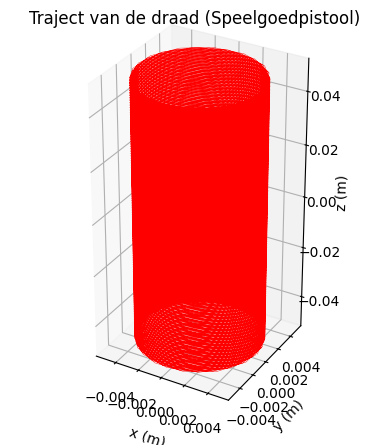

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# speelgoedpistool
l_draad = 20.0     
r_sol = 0.005       
L_sol = 0.1        
I = 0.5          
N_punten = 8000     
omtrek_winding = 2 * np.pi * r_sol
aantal_omwentelingen = l_draad / omtrek_winding

spoed = aantal_omwentelingen / L_sol

print(f"Aantal omwentelingen: {aantal_omwentelingen:.2f}")
print(f"Spoed: {spoed:.2f} windingen per meter")


x, y, z = parametrisatie(N_punten, r_sol, aantal_omwentelingen, L_sol)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
plt.title('Traject van de draad (Speelgoedpistool)')
ax.plot(x, y, z, '-r', linewidth=0.3)

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_box_aspect([1, 1, 2]) # Danders wordt de lange z-component van de draad niet zichtbaar in de grafiek
plt.show()

Het veld in een oneindig lange solenoide wordt gegeven door $\mathbf{H} = n I \hat{\mathbf{z}}$, met $n$ de spoed van de draad, en $I$ de stroom.

**Opdracht 14**

Bereken het veld in het midden van de solenoide en vergelijk het met het analytische antwoord voor een oneindig lange solenoide. Verhoog $N$ net zo lang tot jullie antwoord convergeert naar het analytisch antwoord.
* Denk na over wat dl betekent en hoe jullie deze zou berekenen.
* Bereken met de functie die jullie eerder geschreven hebben de contributies aan het $H$-veld en sommeer deze.

In [10]:
import numpy as np

# 1. functie uit Opdracht 11
def diot_savart_twee(r_field, r_source, dl, I):
    R_vec = r_field - r_source
    R_mag = np.linalg.norm(R_vec)
    R_unit = R_vec / R_mag
    cross_product = np.cross(dl, R_unit)
    dH = (I / (4 * np.pi)) * (cross_product / (R_mag**2))
    return dH

# n = aantal_omwentelingen / L_sol
H_analytisch = spoed * I 

# Numerieke sommatie
r_field = np.array([0, 0, 0]) 
H_totaal_vector = np.array([0.0, 0.0, 0.0])

# We gebruiken de x, y, z arrays die we in opdracht 13 hebben gemaakt
for i in range(len(x) - 1):
    r_source = np.array([x[i], y[i], z[i]])
    
    dl_vector = np.array([x[i+1] - x[i], y[i+1] - y[i], z[i+1] - z[i]])
    
    H_totaal_vector += diot_savart_twee(r_field, r_source, dl_vector, I)

# z-component
H_numeriek = H_totaal_vector[2]

print(f"Analytisch (Oneindig model): {H_analytisch:.2f} A/m")
print(f"Numeriek (pistooltje): {H_numeriek:.2f} A/m")
print(f"Nauwkeurigheid: {(H_numeriek / H_analytisch * 100):.2f}%")

Analytisch (Oneindig model): 3183.10 A/m
Numeriek (pistooltje): 3036.94 A/m
Nauwkeurigheid: 95.41%


**uitleg opdracht**

In deze opdracht hebben een vaste meetpount gebruikt en daar gekeken naar het H-veld. Vanuit da meetpunt hebben we gekeken naar het verschil dat de numerieke (wet van biot-savart) en de analytische (onedige draad) benadering geeft. De conclusie is dat als je het aantal stukjes (dl) waarin je de draad hakt heel groot maakt dsat je heel dicht in de buurt van 100 procent komt. 

### Deel 6: Bereken krachtrespons van een kracht actuator
Omdat onze solenoide niet oneindig lang is zal het veld in de solenoide niet uniform zijn en ook niet op alle plaatsen exact langs de as gericht zijn.

**Opdracht 15**

Bereken de $z$-component van het $\mathbf{H}$-veld op de as van de solenoide over het interval $z \in [0, 1.5L_s]$ in 25 stappen. Je moet nu dus op elk veld-punt met behulp Biot-Savart de bijdragen van alle stroomelementen integreren. Maak een grafiek van de $z$-component van het $\mathbf{H}$-veld tegen $z$.

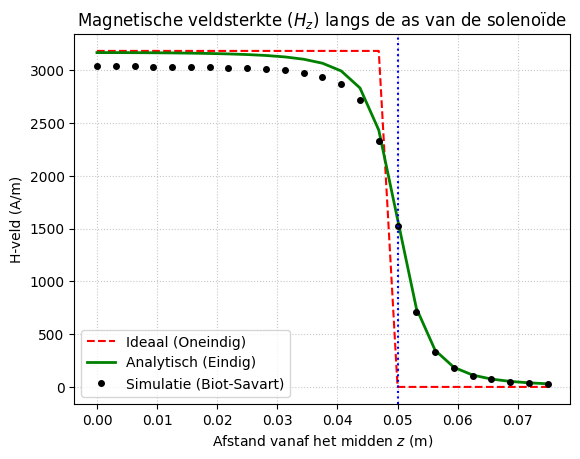

In [11]:
import numpy as np
import matplotlib.pyplot as plt

n_ax = 25
z_ax = np.linspace(0, 1.5 * L_sol / 2, n_ax)
H_ax = np.zeros((n_ax, 1))


# numerieke berekening van het veld langs de as van de spoel
for i_field in range(n_ax):
    r_field = np.array([0, 0, z_ax[i_field]])
    Hsimulated = np.array([0.0, 0.0, 0.0], dtype='float64')
    
    # Over alle segmenten van de solenoïde draad
    for i_src in range(len(x) - 1):
        r_source = np.array([x[i_src], y[i_src], z[i_src]])
        
        # dl: de vector van punt i_src naar i_src + 1
        dl = np.array([x[i_src+1] - x[i_src], 
                       y[i_src+1] - y[i_src], 
                       z[i_src+1] - z[i_src]])
        
        Hsimulated += diot_savart_twee(r_field, r_source, dl, I)

    # z-component
    H_ax[i_field, 0] = Hsimulated[2]
    
# oneindig lange solenoïde (H = n * I)
# Alleen geldig binnen de spoel 
H_ideaal_waarde = (aantal_omwentelingen * I / L_sol)
H_veld_ideaal = H_ideaal_waarde * np.ones(n_ax) * (1.0 * (z_ax <= L_sol / 2))

# Analytisch model voor een eindige solenoïde 
H_veld_analytisch = (aantal_omwentelingen * I / L_sol / 2) * (
    (L_sol / 2 - z_ax) / np.sqrt((z_ax - L_sol / 2)**2 + r_sol**2) +
    (L_sol / 2 + z_ax) / np.sqrt((z_ax + L_sol / 2)**2 + r_sol**2)
)


plt.figure()

plt.plot(z_ax, H_veld_ideaal, '--r', label='Ideaal (Oneindig)')
plt.plot(z_ax, H_veld_analytisch, '-g', label='Analytisch (Eindig)', linewidth=2)
plt.plot(z_ax, H_ax, 'ko', markersize=4, label='Simulatie (Biot-Savart)')

plt.title('Magnetische veldsterkte ($H_z$) langs de as van de solenoïde')
plt.xlabel('Afstand vanaf het midden $z$ (m)')
plt.ylabel('H-veld (A/m)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Extra: markeer de rand van de spoel
plt.axvline(x=L_sol/2, color='blue', linestyle=':', label='Rand spoel')

plt.show()

**uitleg opdracht**

in deze opdracht vergelijken we meerdere benadering om het H-veld te bereknenen. Wat het verschil met opdracht 14 is dat we nu onze meetpunt veranderen en dan kijken naar het H-veld op die plek. Wat zichtbaar is in de grafiek is dat de groen lijn / zwarte stippen afnemen aan de randen (randeffect), terwijl de rode lijn de ideale geeft van een oneindige draad. De  zichtbare afname aan de randen komt omdat het H-veld afbuigt waardoor het afneemt. 

We gaan de solenoide nu gebruiken voor onze krachtactuator. Daarvoor gaan we opnieuw de energie in het magnetisch veld berekenen, maar nu met het numerieke resultaat voor een eindige lengte solenoide. We gaan hier nu een aantal aannames maken:
* We nemen aan het veld alleen een $z$-component heeft en niet afhangt van de afstand tot de solenoide as
* We verwaarlozen de bijdrage aan de energie van het deel van de solenoide gevuld in lucht en integreren alleen het deel van ijzer in het $\mathbf{H}$ veld (dat mag omdat $\mu_r \gg 1$)
* De plunjer is oneindig lang

Zoals je uit je berekening voor het $\mathbf{H}$ kan zien is de energie van de plunjer in de solenoide groter dan voor de plunjer uit de solenoide. Dit komt doordat we de berekening doen met constante stroom. De verplaatsing van de plunjer geeft echter ook een veranderende flux ($d \Phi/dt$) die een tegen EMF geeft. Deze moet overwonnen worden door de stroombron die de arbeid levert. Het magneetveld verricht dus geen arbeid, dat doet de stroombron! We berekenen dit effect hier niet expliciet, maar nemen $-W$ als energie zodat de kracht de juiste kant op wijst (de solenoide in, dus een kracht in de $-z$ richting).


**Opdracht 16**

* Bereken de energie als functie van de afstand van de plunjer in de solenoide met behulp van onderstaand script

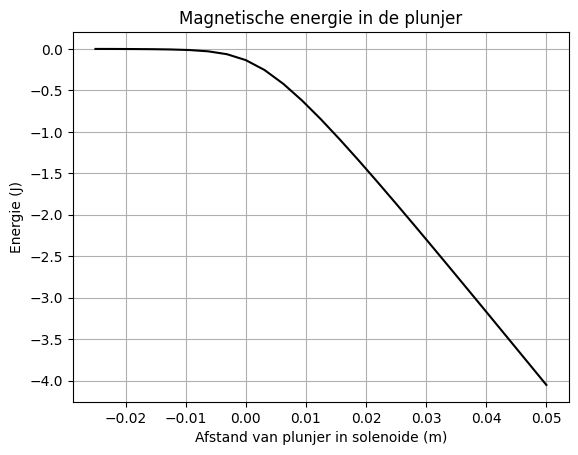

In [16]:
# Energieberekening 
mu_0 = 4 * np.pi * 1e-7
mu_r = 50000 # waarde voor ijzer
I= 0.5

# We gebruiken de parameters van je ontwerp (bijv. speelgoedpistool)
# Als je r_sol en L_sol hebt gebruikt, zorg dat deze namen hier overeenkomen
r_s = r_sol 
L_s = L_sol
dz = z_ax[1] - z_ax[0]

# integreren van het veld (H^2) over het ijzervolume.
# np.flipud zorgt dat we van buiten de spoel naar midden in de spoel rekenen.
Wz = -0.5 * np.pi * r_s**2 * np.cumsum(np.flipud(H_ax[:,0]) * mu_r * mu_0 * np.flipud(H_ax[:,0])) * dz

plt.figure()
plt.plot(L_s/2 - z_ax, np.flipud(Wz), '-k')
plt.title('Magnetische energie in de plunjer')
plt.xlabel('Afstand van plunjer in solenoide (m)')
plt.ylabel('Energie (J)')
plt.grid(True)
plt.show()

**uitleg opdracht**

Als je kijkt naar de grafiek zie je dat de energie constant afneemt, dit geeft aan dat de kracht op de plunjer ook constant is. Ook is zichtbaar dat de er pas magnetische energie in de plunger komt wanneer de plunjer de solonoide binnengaat. Dit komt overeen met de theoprie dat het H-veld buiten de soloide 0 is !!

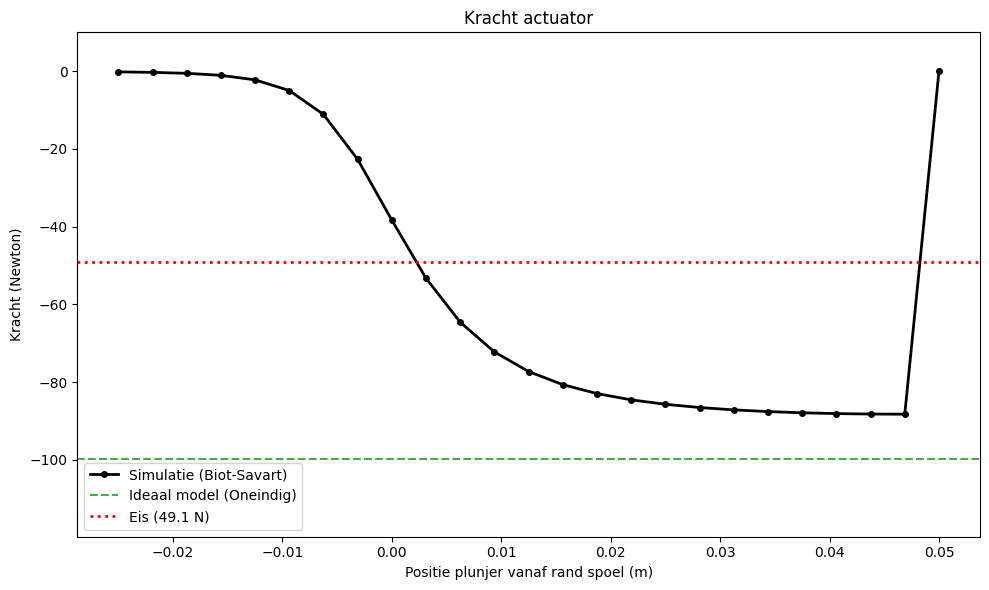

In [17]:
# Krachtberekening 

dz = z_ax[1] - z_ax[0]
kracht_ana  = -mu_0 * mu_r * np.pi * r_s**2 * aantal_omwentelingen**2 * I**2 / (2 * L_s**2)
kracht_num  = np.diff(Wz, n=1, append=[Wz[-1]]) / dz

plt.figure(figsize=(10, 6))

# Afstand van de plunjer 
x_as = L_s/2 - z_ax

# De Numerieke Kracht
plt.plot(x_as, np.flipud(kracht_num), '-o', color='black', linewidth=2, markersize=4, label='Simulatie (Biot-Savart)')

# De Analytische Kracht 
plt.axhline(y=kracht_ana, color='green', linestyle='--', alpha=0.7, label='Ideaal model (Oneindig)')

# De Benodigde Kracht 
eis_kracht = -5 * 9.81
plt.axhline(y=eis_kracht, color='red', linestyle=':', linewidth=2, label=f'Eis ({abs(eis_kracht):.1f} N)')

plt.title('Kracht actuator')
plt.xlabel('Positie plunjer vanaf rand spoel (m)')
plt.ylabel('Kracht (Newton)')

y_min = min(np.min(kracht_num), eis_kracht, kracht_ana) * 1.2
plt.ylim([y_min, 10]) 
plt.legend()
plt.tight_layout()
plt.show()

**uitleg opdracht**

Hier is zichtbaar dat de kracht indedaad constant is. Ook is zichtbaar dat het ideaal model afwijkt van de simulatie zodra we buiten de solonoide gaan. 

Wat wel zichtbaar is dat ons pistooltje een veel te lage kracht levert. Hoe kunnen we dit fixen;
- verhoog stroom (I) || F is rechtevenredig met $I^2$
- windingen per meter (n) || F is recht evenredig met $n^2$
- straal (r) || F is recht evenredig met $r^2$

### Deel 7: Beoordeling van de criteria
**Opdracht 17**

Kijk in deze vraag terug naar de criteria die jullie voor de deuractuator hebben opgesteld. Voldoet jullie ontwerp aan alle gestelde criteria?


Plaats hier jullie evaluatie of de deur actuator aan de minimale kracht eis voldoet

hij voldoet aan de criteria, de simulatie laat zien dat de kracht tot ongeveer 90 N oploopt zodra de plunjer in de spoel zit (boven de eis)

**Opdracht 18**

Voer opdrachten 15 en 16 uit voor jouw eigen gekozen toepassingen.

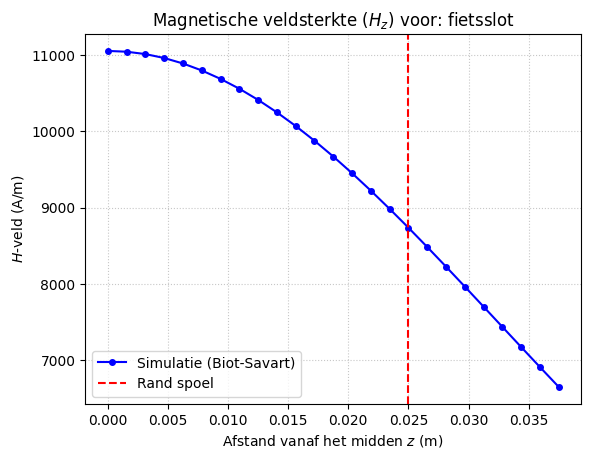

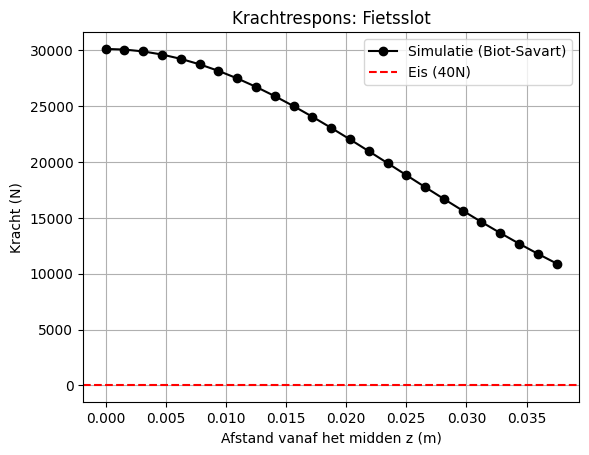

In [18]:


I = I_fiets
r_sol = r_fiets
L_sol = 0.05 
aantal_omwentelingen = 645 
F_eis = 40

x, y, z = parametrisatie(8000, r_sol, aantal_omwentelingen, L_sol)

n_ax = 25
z_ax = np.linspace(0, 1.5 * L_sol / 2, n_ax)
H_ax = np.zeros((n_ax, 1))

for i_field in range(n_ax):
    r_field = np.array([0, 0, z_ax[i_field]])
    Hsimulated = np.array([0.0, 0.0, 0.0], dtype='float64')
    for i_src in range(len(x) - 1):
        r_source = np.array([x[i_src], y[i_src], z[i_src]])
        dl = np.array([x[i_src+1] - x[i_src], y[i_src+1] - y[i_src], z[i_src+1] - z[i_src]])
        Hsimulated += diot_savart_twee(r_field, r_source, dl, I)
    H_ax[i_field, 0] = Hsimulated[2]

# Krachtberekening specifiek voor fietsslot
A = np.pi * r_sol**2
F_vals = 0.5 * mu_0 * (mu_r - 1) * A * (H_ax**2)


plt.figure()
plt.plot(z_ax, H_ax, 'bo-', markersize=4, label='Simulatie (Biot-Savart)')
plt.title(f'Magnetische veldsterkte ($H_z$) voor: fietsslot')
plt.xlabel('Afstand vanaf het midden $z$ (m)')
plt.ylabel('$H$-veld (A/m)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.axvline(x=L_sol/2, color='red', linestyle='--', label='Rand spoel')
plt.legend()
plt.show()

plt.figure()
plt.plot(z_ax, F_vals, 'ko-', label='Simulatie (Biot-Savart)')
plt.axhline(y=F_eis, color='r', linestyle='--', label=f'Eis ({F_eis}N)')
plt.title('Krachtrespons: Fietsslot')
plt.xlabel('Afstand vanaf het midden z (m)')
plt.ylabel('Kracht (N)')
plt.grid(True)
plt.legend()
plt.show()

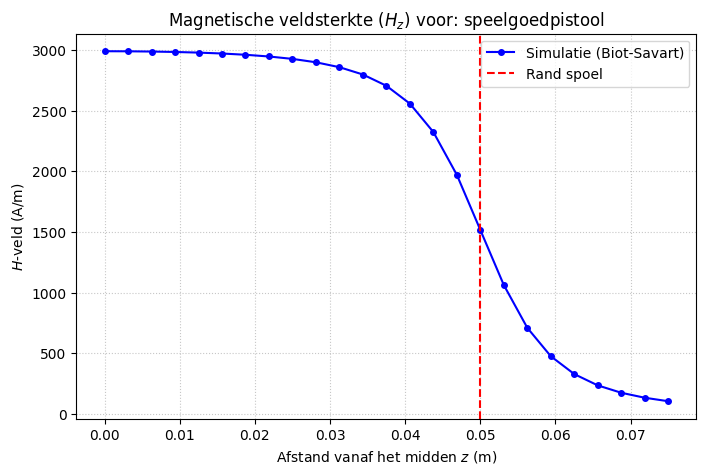

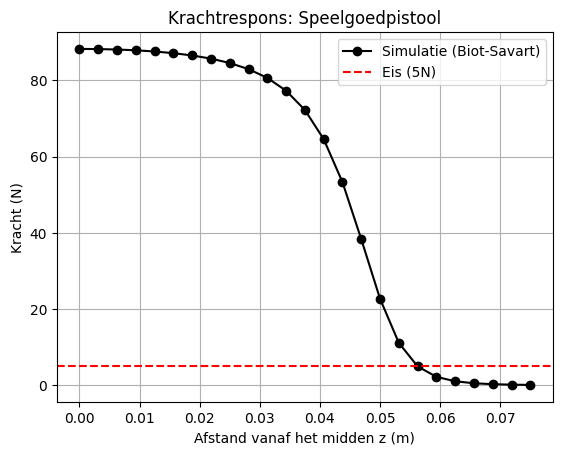

In [15]:

I = I_pistool
r_sol = r_pistool
L_sol = 0.10 
aantal_omwentelingen = 636
F_eis = 5

x, y, z = parametrisatie(8000, r_sol, aantal_omwentelingen, L_sol)

n_ax = 25
z_ax = np.linspace(0, 1.5 * L_sol / 2, n_ax)
H_ax = np.zeros((n_ax, 1))

for i_field in range(n_ax):
    r_field = np.array([0, 0, z_ax[i_field]])
    Hsimulated = np.array([0.0, 0.0, 0.0], dtype='float64')
    for i_src in range(len(x) - 1):
        r_source = np.array([x[i_src], y[i_src], z[i_src]])
        dl = np.array([x[i_src+1] - x[i_src], y[i_src+1] - y[i_src], z[i_src+1] - z[i_src]])
        Hsimulated += diot_savart_twee(r_field, r_source, dl, I)
    H_ax[i_field, 0] = Hsimulated[2]

# Krachtberekening specifiek voor speelgoedpistool
A = np.pi * r_sol**2
F_vals = 0.5 * mu_0 * (mu_r - 1) * A * (H_ax**2)

plt.figure(figsize=(8, 5))
plt.plot(z_ax, H_ax, 'bo-', markersize=4, label='Simulatie (Biot-Savart)')
plt.title(f'Magnetische veldsterkte ($H_z$) voor: speelgoedpistool')
plt.xlabel('Afstand vanaf het midden $z$ (m)')
plt.ylabel('$H$-veld (A/m)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.axvline(x=L_sol/2, color='red', linestyle='--', label='Rand spoel')
plt.legend()
plt.show()

plt.figure()
plt.plot(z_ax, F_vals, 'ko-', label='Simulatie (Biot-Savart)')
plt.axhline(y=F_eis, color='r', linestyle='--', label=f'Eis ({F_eis}N)')
plt.title('Krachtrespons: Speelgoedpistool')
plt.xlabel('Afstand vanaf het midden z (m)')
plt.ylabel('Kracht (N)')
plt.grid(True)
plt.legend()
plt.show()

**Opdracht 19**

a. Kijk terug naar de criteria die jullie hebben opgesteld in vraag 5. Hebben jullie nu genoeg informatie om te beoordelen of jullie ontwerp voldoet aan de gestelde criteria, zo nee ontwerp een simpel experiment waarmee jullie het wel zouden uit kunnen voeren.
b. Beoordeel op basis van de criteria die jullie wel kunnen beoordelen of jullie idee voldoet aan jullie criteria.

Edit deze cel met jullie antwoorden op vraag 19.

a) we hebben genoeg info om de gestelde criteria te beoordelen, alleen de zelf bedachte criteria heben we niet genoeg informatie voor, want we hebben alleen de kracht. \
als experiment om deze criteria wel te checken zou je:\
 voor het speelgoedpistool een slowmotion video maken van de spoel, waarna je het aantal frames telt tussen het sluiten van de schakelaar en het moment dat de plunjer zijn maximale uitslag bereikt. hiermee kan je de reactietijd meten. \
 voor het fietsslot kan je met een thermometen meten hoelang het duurt als je de spoel aanzet voordat hij op een te warme temperatuur is, waarbij je het aantal wikkeling telt zodat je kan zien of het gekozen aantal aan de criteria voldoet. 

b)fietsslot: de kracht is hier veel hoger dan de eis, dus die voldoet goed.\
speelgoedpistool: de kracht is hier veel hoger dan de eis, dus die voldoet aan de criteria.

Controleer eerst nog goed of alles klopt. **Klik boven op `Kernel -> Restart and Run all` en check of er geen errors zijn**. Zorg dat alle benodigde bestanden zijn geüpload in de juiste map en dat de afbeeldingen zichtbaar zijn in het notebook. Je kan nu jouw notebook opslaan, comitten en pushen naar de juiste branch! Maak dan de pull request aan en lever die in in brightspace.